# Mountain car environment for the DQN

Please check the environment [webpage](https://gymnasium.farama.org/environments/classic_control/mountain_car/) and undertand the action space, observation space and state of the MDP.

Then study the following code and experiment with the parameters.

In [ ]:

%matplotlib inline
# Install dependencies (only needed once)
!pip install gymnasium[classic_control] matplotlib imageio ffmpeg 1>/dev/null 2>/dev/null


In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
import os
import glob
from base64 import b64encode
from IPython.display import HTML
from IPython.display import clear_output

plt.ion()

In [ ]:
# Hyperparameters
gamma = 0.99
lr = 1e-3
batch_size = 64
epsilon_start = 1.0
epsilon_end = 0.01
epsilon_decay = 500
target_update = 10
buffer_limit = 10000
num_episodes = 2000

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:

# Q-network
class QNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.layers(x)

# Replay buffer
class ReplayBuffer:
    def __init__(self):
        self.buffer = deque(maxlen=buffer_limit)

    def put(self, transition):
        self.buffer.append(transition)

    def sample(self, n):
        batch = random.sample(self.buffer, n)
        s, a, r, s_, done = zip(*batch)
        return (
            torch.tensor(s, dtype=torch.float32).to(device),
            torch.tensor(a, dtype=torch.int64).unsqueeze(1).to(device),
            torch.tensor(r, dtype=torch.float32).unsqueeze(1).to(device),
            torch.tensor(s_, dtype=torch.float32).to(device),
            torch.tensor(done, dtype=torch.float32).unsqueeze(1).to(device),
        )

    def size(self):
        return len(self.buffer)


In [ ]:
# Epsilon-greedy action selection
def epsilon_greedy(q, state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()
    else:
        with torch.no_grad():
            state_tensor = torch.tensor([state], dtype=torch.float32).to(device)
            return q(state_tensor).argmax().item()



In [ ]:
# Training step
def train(q, q_target, memory, optimizer):
    if memory.size() < batch_size:
        return
    s, a, r, s_, done = memory.sample(batch_size)
    q_out = q(s).gather(1, a)
    max_q_prime = q_target(s_).max(1)[0].unsqueeze(1)
    target = r + gamma * max_q_prime * (1 - done)
    loss = nn.MSELoss()(q_out, target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



# Setup environment with video
video_dir = "./videos"
env = gym.make("MountainCar-v0", render_mode="rgb_array")
env = gym.wrappers.RecordVideo(env, video_folder=video_dir, episode_trigger=lambda e: e % 50 == 0)



/usr/local/lib/python3.11/dist-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [ ]:
# Init agent
q = QNetwork(2, 3).to(device)
q_target = QNetwork(2, 3).to(device)
q_target.load_state_dict(q.state_dict())
memory = ReplayBuffer()
optimizer = optim.Adam(q.parameters(), lr=lr)



In [ ]:
episode_video_files = {}  # Maps episode number to video path
episode_rewards = []      # Stores (episode, reward) tuples

In [ ]:
def reward_fn(state):
    return -np.abs(state[0] - 0.5) + 100*(state[0] >= 0.5)


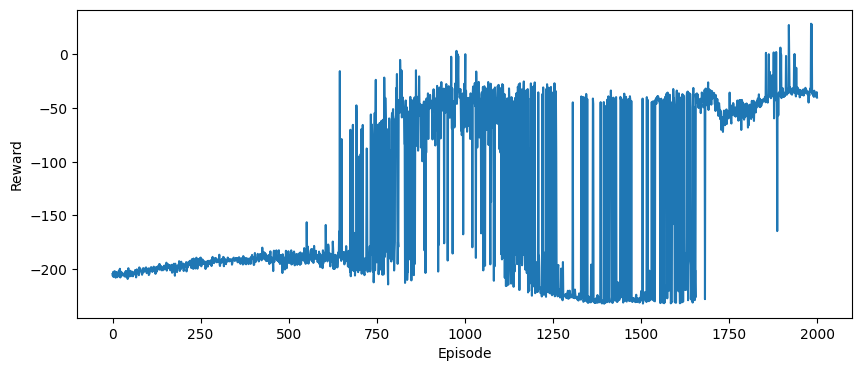

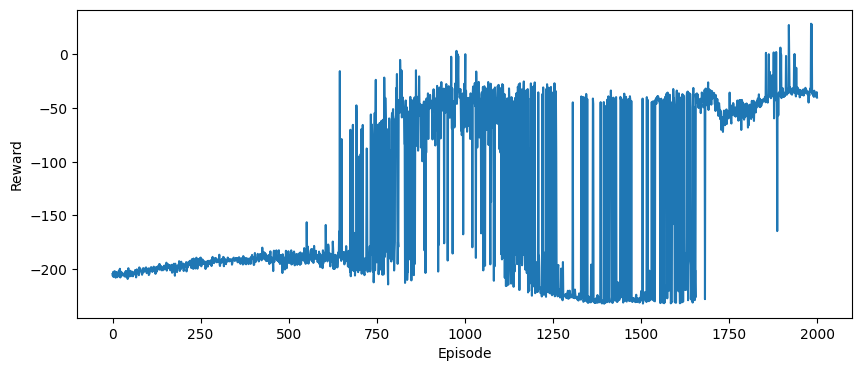

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
line, = ax.plot([], [], label="Reward per Episode")
ax.set_xlim(0, num_episodes)
ax.set_ylim(-200, 100)
ax.set_xlabel("Episode")
ax.set_ylabel("Reward")
ax.grid(True)
ax.legend()

# Training loop
reward_history = []
for episode in range(num_episodes):
    state, _ = env.reset()
    epsilon = epsilon_end + (epsilon_start - epsilon_end) * np.exp(-1. * episode / epsilon_decay)
    done = False
    total_reward = 0

    while not done:
        action = epsilon_greedy(q, state, epsilon)
        next_state, time_, terminated, truncated, _ = env.step(action)

        #log to file, including episode number, action, state, next_state
        with open("log.txt", "a") as f:
            f.write(f"{episode},{action},{state},{next_state}\n")


        # Encourage reaching the goal
        reward = reward_fn(next_state)
        done = terminated or truncated

        memory.put((state, action, reward, next_state, done))
        state = next_state
        total_reward += reward

        train(q, q_target, memory, optimizer)

    if episode % target_update == 0:
        q_target.load_state_dict(q.state_dict())

    reward_history.append(total_reward)


    # Store video filename if one was recorded
    if episode % 50 == 0:
        # Save episode-reward pair
        episode_rewards.append((episode, total_reward))
        # Find latest video file
        mp4_list = sorted(glob.glob(os.path.join(video_dir, "*.mp4")), key=os.path.getctime)
        if mp4_list:
            episode_video_files[episode] = mp4_list[-1]
    print(f"Episode {episode}, Reward: {total_reward:.1f}, Epsilon: {epsilon:.3f}")

    clear_output(wait=True)
    plt.figure(1)
    plt.clf()
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.plot(reward_history)
    #plt.pause(0.001)
    display(plt.gcf())


env.close()

In [ ]:
# Sort episodes by reward
sorted_rewards = sorted(episode_rewards, key=lambda x: x[1])
worst_episode, worst_reward = sorted_rewards[0]
best_episode, best_reward = sorted_rewards[-1]
median_episode, median_reward = sorted_rewards[len(sorted_rewards) // 2]
print(f"Best episode: {best_episode}, Reward: {best_reward}")
print(f"Worst episode: {worst_episode}, Reward: {worst_reward}")
print(f"Median episode: {median_episode}, Reward: {median_reward}")

Best episode: 1150, Reward: -30.171658277511597
Worst episode: 1400, Reward: -229.5774209499359
Median episode: 600, Reward: -186.62580931186676


In [ ]:
def show_video_for_episode(ep_number):
    path = episode_video_files.get(ep_number)
    if path is None:
        print(f"No video for episode {ep_number}")
        return
    mp4 = open(path, 'rb').read()
    b64 = b64encode(mp4).decode()
    return HTML(f'<video width="640" height="480" controls><source src="data:video/mp4;base64,{b64}" type="video/mp4"></video>')


In [ ]:
# Show best episode video
show_video_for_episode(best_episode)

In [ ]:
# Show worst:
show_video_for_episode(worst_episode)

In [ ]:
# median
show_video_for_episode(median_episode)